In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.signal import butter, filtfilt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import seaborn as sns

In [24]:
def whale_denoise(y, sr, low_freq=20, high_freq=1000):
    """
    Специализированное шумоподавление для низкочастотных китовых звуков
    """
    try:
        # 1. Bandpass фильтр для частот китов
        def butter_bandpass(lowcut, highcut, fs, order=4):
            nyq = 0.5 * fs
            low = lowcut / nyq
            high = highcut / nyq
            b, a = butter(order, [low, high], btype='band')
            return b, a
        
        b, a = butter_bandpass(low_freq, high_freq, sr)
        y_filtered = filtfilt(b, a, y)
        
        # 2. Spectral subtraction
        D = librosa.stft(y_filtered, n_fft=2048, hop_length=512)
        magnitude = np.abs(D)
        phase = np.angle(D)
        
        # Оценка шума по первым 0.2 секундам
        noise_frames = magnitude[:, :int(0.2 * sr / 512)]
        noise_profile = np.median(noise_frames, axis=1)
        
        # Мягкое spectral subtraction
        threshold = 1.5 * noise_profile.reshape(-1, 1)
        magnitude_clean = np.maximum(magnitude - threshold, 0.001)
        
        # Восстановление сигнала
        D_clean = magnitude_clean * np.exp(1j * phase)
        y_clean = librosa.istft(D_clean)
        
        return y_clean
        
    except Exception as e:
        print(f"Ошибка в шумоподавлении: {e}")
        return y

In [25]:

def compare_spectrograms(audio_file, label, fmax=2000, sr=22050):
    """
    Сравнение спектрограмм до и после шумоподавления
    """
    try:
        y_orig, sr = librosa.load(audio_file, sr=sr, duration=2.0)
        y_clean = whale_denoise(y_orig, sr)
        filename = audio_file.stem
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 8))
        
        # 1. Mel-spectrogram
        spec_orig = librosa.feature.melspectrogram(y=y_orig, sr=sr, n_mels=128, fmax=fmax)
        spec_orig_db = librosa.power_to_db(spec_orig, ref=np.max)
        librosa.display.specshow(spec_orig_db, sr=sr, x_axis='time', y_axis='mel', 
                               ax=axes[0, 0], cmap='viridis', fmax=fmax)
        axes[0, 0].set_title(f'Mel-spectrogram\nДО')
        
        spec_clean = librosa.feature.melspectrogram(y=y_clean, sr=sr, n_mels=128, fmax=fmax)
        spec_clean_db = librosa.power_to_db(spec_clean, ref=np.max)
        librosa.display.specshow(spec_clean_db, sr=sr, x_axis='time', y_axis='mel', 
                               ax=axes[1, 0], cmap='viridis', fmax=fmax)
        axes[1, 0].set_title(f'Mel-spectrogram\nПОСЛЕ')
        
        # 2. STFT с fmax
        n_fft = 2048
        hop_length = 512
        
        # STFT ДО
        D_orig = librosa.stft(y_orig, n_fft=n_fft, hop_length=hop_length)
        D_orig_db = librosa.amplitude_to_db(np.abs(D_orig), ref=np.max)
        librosa.display.specshow(D_orig_db, sr=sr, hop_length=hop_length,
                               x_axis='time', y_axis='hz', ax=axes[0, 1], 
                               cmap='plasma', fmax=fmax)
        axes[0, 1].set_title(f'STFT\nДО')
        
        # STFT ПОСЛЕ
        D_clean = librosa.stft(y_clean, n_fft=n_fft, hop_length=hop_length)
        D_clean_db = librosa.amplitude_to_db(np.abs(D_clean), ref=np.max)
        img = librosa.display.specshow(D_clean_db, sr=sr, hop_length=hop_length,
                                     x_axis='time', y_axis='hz', ax=axes[1, 1], 
                                     cmap='plasma', fmax=fmax)
        axes[1, 1].set_title(f'STFT\nПОСЛЕ')
        
        # 3. Chromagram
        chroma_orig = librosa.feature.chroma_stft(y=y_orig, sr=sr)
        librosa.display.specshow(chroma_orig, sr=sr, x_axis='time', y_axis='chroma',
                               ax=axes[0, 2], cmap='coolwarm')
        axes[0, 2].set_title('Chromagram\nДО')
        
        chroma_clean = librosa.feature.chroma_stft(y=y_clean, sr=sr)
        librosa.display.specshow(chroma_clean, sr=sr, x_axis='time', y_axis='chroma',
                               ax=axes[1, 2], cmap='coolwarm')
        axes[1, 2].set_title('Chromagram\nПОСЛЕ')
        
        # Добавляем информацию о классе
        for i in range(2):
            for j in range(3):
                axes[i, j].text(0.02, 0.98, f'Класс: {"КИТ" if label == 1 else "НЕТ КИТА"}', 
                              transform=axes[i, j].transAxes, fontsize=9,
                              verticalalignment='top', 
                              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.colorbar(img, ax=axes[1, 1], fraction=0.046, pad=0.04)
        plt.suptitle(f'Сравнение спектрограмм: {filename}\nЧастотный диапазон: 0-{fmax} Hz', 
                     fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()
        
        return fig
        
    except Exception as e:
        print(f"Ошибка при обработке файла {audio_file}: {e}")
        return None


In [26]:
def extract_spectral_features(y, sr, n_mels=128, n_mfcc=13, fmax=2000):
    """
    Извлечение ключевых признаков из различных спектрограмм
    """
    features = {}
    
    try:
        # 1. MEL-СПЕКТРОГРАММА
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=fmax)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Признаки из Mel-спектрограммы
        features['mel_spectral_centroid'] = np.mean(librosa.feature.spectral_centroid(S=mel_spec))
        features['mel_spectral_bandwidth'] = np.mean(librosa.feature.spectral_bandwidth(S=mel_spec))
        features['mel_spectral_rolloff'] = np.mean(librosa.feature.spectral_rolloff(S=mel_spec))
        features['mel_spectral_flatness'] = np.mean(librosa.feature.spectral_flatness(S=mel_spec))
        
        # Статистики по Mel-спектрограмме
        features['mel_mean'] = np.mean(mel_spec_db)
        features['mel_std'] = np.std(mel_spec_db)
        features['mel_max'] = np.max(mel_spec_db)
        
        # 2. STFT-СПЕКТРОГРАММА
        stft = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))
        stft_db = librosa.amplitude_to_db(stft, ref=np.max)
        
        # Признаки из STFT
        features['stft_spectral_centroid'] = np.mean(librosa.feature.spectral_centroid(S=stft))
        features['stft_spectral_rolloff'] = np.mean(librosa.feature.spectral_rolloff(S=stft))
        features['stft_energy'] = np.sum(stft ** 2) / len(stft.flatten())
        
        # Статистики по STFT
        features['stft_mean'] = np.mean(stft_db)
        features['stft_std'] = np.std(stft_db)
        
        # 3. MFCC
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        
        # Статистики по MFCC (первые 5 коэффициентов самые важные)
        for i in range(min(8, n_mfcc)):
            features[f'mfcc_{i}_mean'] = np.mean(mfccs[i])
            features[f'mfcc_{i}_std'] = np.std(mfccs[i])
        
        # 4. CHROMA-ПРИЗНАКИ
        chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
        features['chroma_stft_mean'] = np.mean(chroma_stft)
        features['chroma_stft_std'] = np.std(chroma_stft)
        
        # 5. SPECTRAL CONTRAST
        spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=50.0)
        features['spectral_contrast_mean'] = np.mean(spectral_contrast)
        
        # 6. TEMPORAL FEATURES
        features['zcr_mean'] = np.mean(librosa.feature.zero_crossing_rate(y))
        features['rms_mean'] = np.mean(librosa.feature.rms(y=y))
        
        # 7. LOW-FREQUENCY ENERGY
        freqs = librosa.fft_frequencies(sr=sr, n_fft=2048)
        low_freq_mask = (freqs >= 10) & (freqs <= 500)
        if np.any(low_freq_mask):
            low_freq_energy = np.mean(stft_db[low_freq_mask, :])
            features['low_freq_energy'] = low_freq_energy
        else:
            features['low_freq_energy'] = 0
            
    except Exception as e:
        print(f"Ошибка при извлечении признаков: {e}")
    
    return features

In [27]:
def create_spectral_features_dataset(audio_files, labels_df, sr=22050, use_denoising=True):
    """
    Создание датасета с признаками из спектрограмм
    """
    features_list = []
    labels_list = []
    filenames_list = []
    
    for i, audio_file in enumerate(audio_files):
        try:
            if i % 100 == 0:
                print(f"Обработано {i}/{len(audio_files)} файлов...")
            
            # Загрузка аудио
            y, sr = librosa.load(audio_file, sr=sr, duration=2.0)
            
            # Шумоподавление
            if use_denoising:
                y_processed = whale_denoise(y, sr)
            else:
                y_processed = y
            
            # Извлечение признаков
            features = extract_spectral_features(y_processed, sr)
            
            # Получение метки
            filename = audio_file.name
            matching_row = labels_df[labels_df['clip_name'] == filename]
            
            if not matching_row.empty:
                label = matching_row['label'].iloc[0]
                
                features_list.append(features)
                labels_list.append(label)
                filenames_list.append(filename)
            
        except Exception as e:
            print(f"Ошибка обработки {audio_file}: {e}")
            continue
    
    # Преобразование в DataFrame
    features_df = pd.DataFrame(features_list)
    features_df['label'] = labels_list
    features_df['filename'] = filenames_list
    
    print(f"\nУспешно обработано: {len(features_df)} файлов")
    print(f"Размерность признаков: {features_df.shape[1] - 2} признаков")
    
    return features_df

In [28]:
def analyze_feature_importance(features_df, top_k=20):
    """
    Анализ важности признаков
    """
    # Подготовка данных
    X = features_df.drop(['label', 'filename'], axis=1, errors='ignore')
    y = features_df['label']
    
    # Заполнение пропущенных значений
    X = X.fillna(X.mean())
    
    # Масштабирование
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Обучение Random Forest для анализа важности
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_scaled, y)
    
    # Важность признаков
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Визуализация
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(top_k)
    
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Важность признака')
    plt.title(f'Топ-{top_k} самых важных признаков')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("Топ-10 самых важных признаков:")
    for i, row in top_features.head(10).iterrows():
        print(f"{row['feature']}: {row['importance']:.4f}")
    
    return feature_importance, top_features

In [29]:
def select_top_features(features_df, top_features_list):
    """
    Выбор только самых важных признаков
    """
    # Проверяем, какие признаки существуют в DataFrame
    existing_features = [f for f in top_features_list if f in features_df.columns]
    selected_features = features_df[existing_features + ['label', 'filename']]
    return selected_features

In [30]:
def train_on_spectral_features(audio_files, labels_df, test_size=0.2, use_top_features=True):
    """
    Полный пайплайн: извлечение признаков -> отбор -> обучение
    """
    print("🎯 ЗАПУСК ПОЛНОГО ПАЙПЛАЙНА ОБУЧЕНИЯ")
    
    # 1. Извлечение признаков
    print("1. Извлечение признаков из спектрограмм...")
    features_df = create_spectral_features_dataset(audio_files, labels_df, use_denoising=True)
    
    # 2. Анализ важности признаков
    print("2. Анализ важности признаков...")
    feature_importance, top_features = analyze_feature_importance(features_df)
    
    # 3. Выбор лучших признаков
    if use_top_features:
        top_feature_names = top_features['feature'].head(25).tolist()
        features_df = select_top_features(features_df, top_feature_names)
        print(f"3. Выбрано {len(top_feature_names)} самых важных признаков")
    
    # 4. Подготовка данных для ML
    X = features_df.drop(['label', 'filename'], axis=1)
    y = features_df['label']
    
    # Заполнение пропусков
    X = X.fillna(X.mean())
    
    # Масштабирование
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Разделение на train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )
    
    print(f"4. Данные подготовлены: {X_train.shape[0]} train, {X_test.shape[0]} test")
    
    return X_train, X_test, y_train, y_test, features_df, feature_importance

In [31]:
import os
from pathlib import Path
#Файлы
large_data_path = r'F:\datasets\whale-detection-challenge\whale_data\data' 
train_path = Path(large_data_path) / 'train'
test_path = Path(large_data_path) / 'test'

#Метки
train_csv_path = Path(large_data_path) / 'train.csv'
train_df = pd.read_csv(train_csv_path)

train_df = train_df.rename(columns={'clip_name_label': 'filename', 'train1.atif,0': 'label'})

train_audio_files = list(train_path.rglob('*.aiff')) + list(train_path.rglob('*.aif'))
test_audio_files = list(test_path.rglob('*.aiff')) + list(test_path.rglob('*.aif'))

print(f"Размер датасета: {len(train_df)}")
print(f"Распределение меток:\n{train_df['label'].value_counts()}")

Размер датасета: 30000
Распределение меток:
label
0    22973
1     7027
Name: count, dtype: int64


🚀 ЗАПУСК ОБУЧЕНИЯ НА ПРИЗНАКАХ ИЗ СПЕКТРОГРАММ
🎯 ЗАПУСК ПОЛНОГО ПАЙПЛАЙНА ОБУЧЕНИЯ
1. Извлечение признаков из спектрограмм...
Обработано 0/500 файлов...
Обработано 100/500 файлов...
Обработано 200/500 файлов...
Обработано 300/500 файлов...
Обработано 400/500 файлов...

Успешно обработано: 500 файлов
Размерность признаков: 34 признаков
2. Анализ важности признаков...


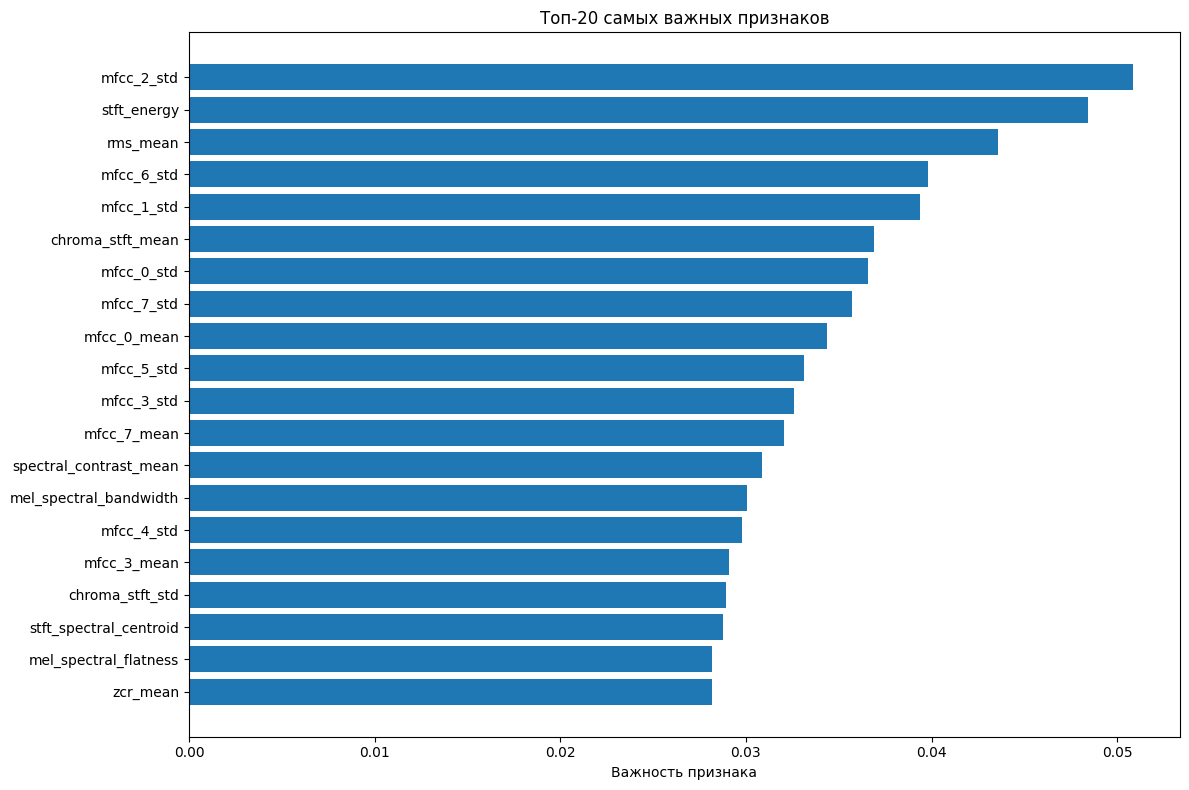

Топ-10 самых важных признаков:
mfcc_2_std: 0.0508
stft_energy: 0.0484
rms_mean: 0.0436
mfcc_6_std: 0.0398
mfcc_1_std: 0.0394
chroma_stft_mean: 0.0369
mfcc_0_std: 0.0366
mfcc_7_std: 0.0357
mfcc_0_mean: 0.0344
mfcc_5_std: 0.0331
3. Выбрано 20 самых важных признаков
4. Данные подготовлены: 400 train, 100 test

📊 СРАВНЕНИЕ МОДЕЛЕЙ:
Random Forest: 0.7300
XGBoost: 0.7400
SVM: 0.7400
Logistic Regression: 0.6900

🎯 ЛУЧШАЯ МОДЕЛЬ: XGBoost
📈 ОТЧЕТ ПО КЛАССИФИКАЦИИ:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83        70
           1       0.60      0.40      0.48        30

    accuracy                           0.74       100
   macro avg       0.69      0.64      0.65       100
weighted avg       0.72      0.74      0.72       100



In [32]:
 # Сначала протестируем на маленькой выборке
sample_files = train_audio_files[:500]  # первые 500 файлов для теста
    
print("🚀 ЗАПУСК ОБУЧЕНИЯ НА ПРИЗНАКАХ ИЗ СПЕКТРОГРАММ")
X_train, X_test, y_train, y_test, features_df, importance = train_on_spectral_features(
    sample_files, train_df, use_top_features=True
)
    
# Обучение моделей
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True),
    'Logistic Regression': LogisticRegression(random_state=42)
}
    
print("\n📊 СРАВНЕНИЕ МОДЕЛЕЙ:")
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name}: {accuracy:.4f}")
    
# Лучшая модель
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
    
print(f"\n🎯 ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print("📈 ОТЧЕТ ПО КЛАССИФИКАЦИИ:")
print(classification_report(y_test, y_pred_best))

🔊 ВИЗУАЛИЗАЦИЯ СПЕКТРОГРАММ

📊 Файл БЕЗ кита: train1.aiff


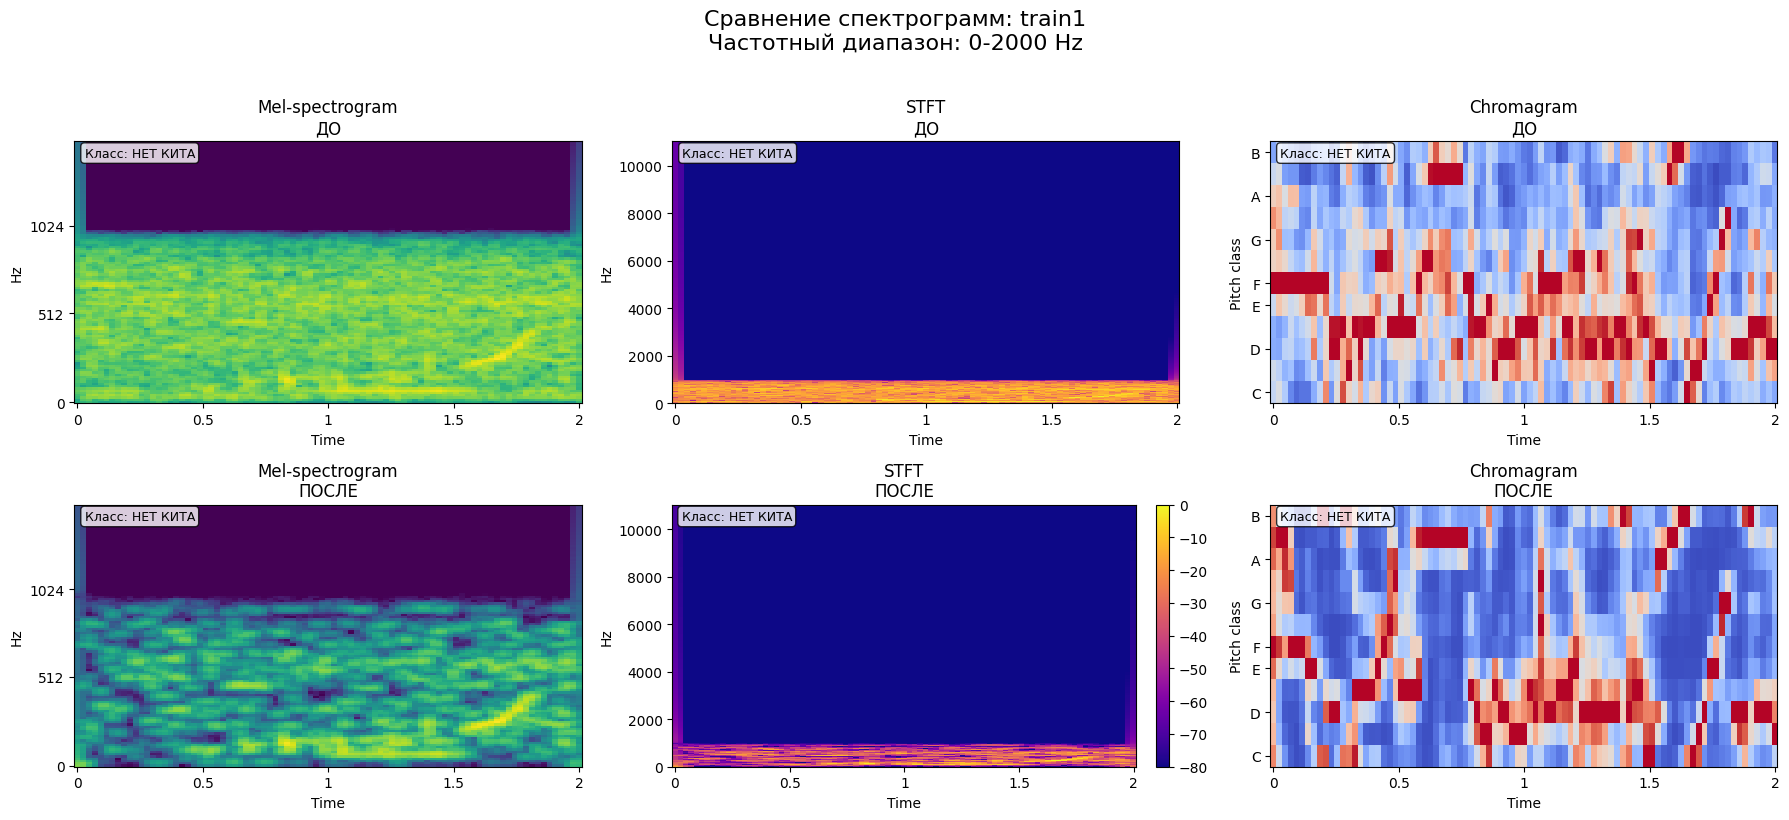


📊 Файл С китом: train1000.aiff


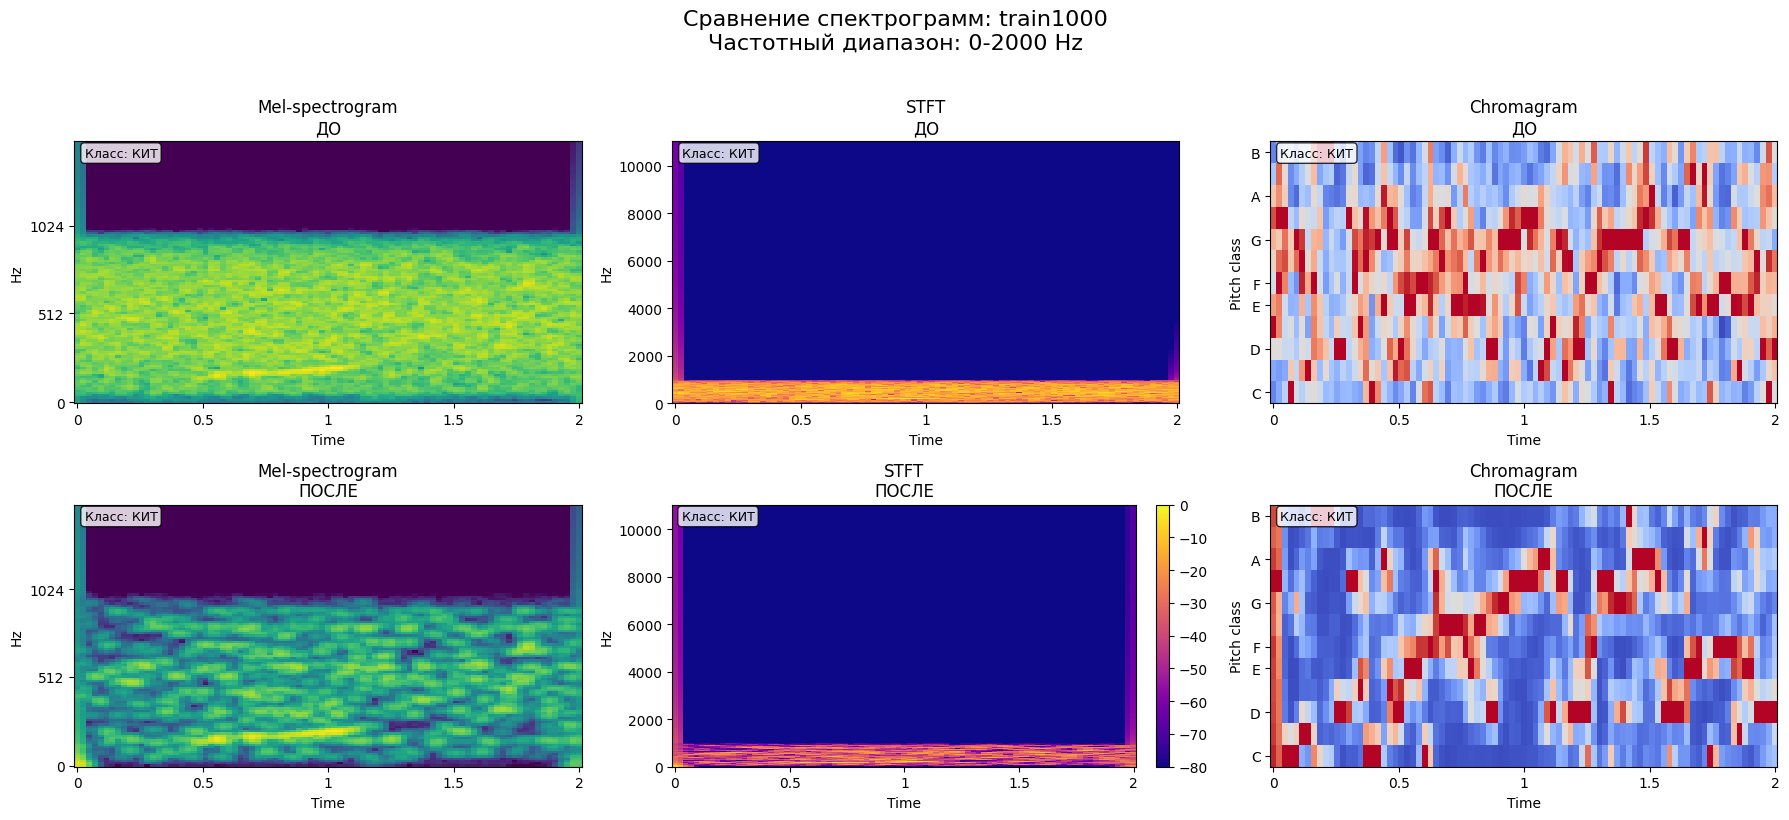

In [33]:
# ВИЗУАЛИЗАЦИЯ СПЕКТРОГРАММ ДО И ПОСЛЕ ШУМОПОДАВЛЕНИЯ
print("🔊 ВИЗУАЛИЗАЦИЯ СПЕКТРОГРАММ")

# Находим по одному файлу каждого класса для демонстрации
class_0_sample = None
class_1_sample = None

for audio_file in train_audio_files[:200]:
    filename = audio_file.name
    matching_row = train_df[train_df['clip_name'] == filename]
    if not matching_row.empty:
        label = matching_row['label'].iloc[0]
        if label == 0 and class_0_sample is None:
            class_0_sample = audio_file
        elif label == 1 and class_1_sample is None:
            class_1_sample = audio_file
        
        if class_0_sample and class_1_sample:
            break
# Визуализируем спектрограммы для каждого класса
if class_0_sample:
    print(f"\n📊 Файл БЕЗ кита: {class_0_sample.name}")
    compare_spectrograms(class_0_sample, label=0)

if class_1_sample:
    print(f"\n📊 Файл С китом: {class_1_sample.name}")
    compare_spectrograms(class_1_sample, label=1)



📈 ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ КЛАССОВ НА ПЛОСКОСТИ

📊 РАСПРЕДЕЛЕНИЕ КЛАССОВ НА ТРЕНИРОВОЧНЫХ ДАННЫХ


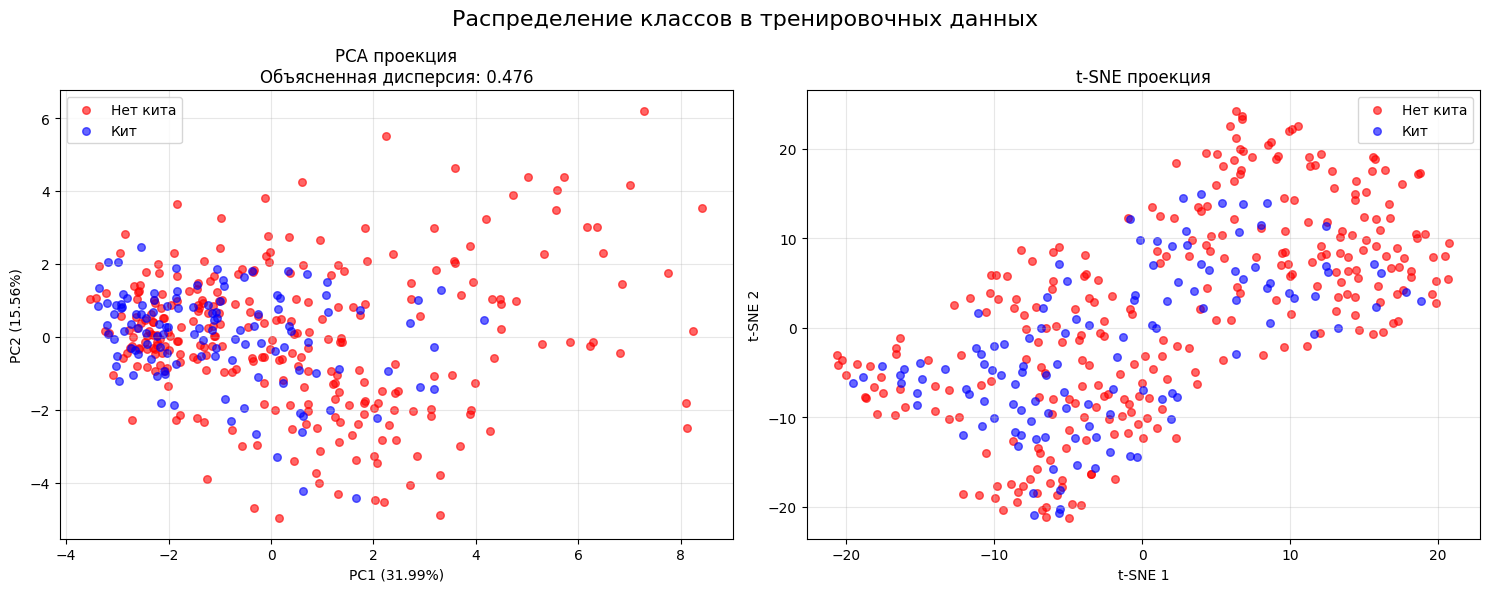

🔍 АНАЛИЗ РАЗДЕЛИМОСТИ:
Разделение по PC1: 1.456
✅ Классы хорошо разделяются линейно
   Рекомендуются: Logistic Regression, Linear SVM

📊 РАСПРЕДЕЛЕНИЕ КЛАССОВ НА ТЕСТОВЫХ ДАННЫХ


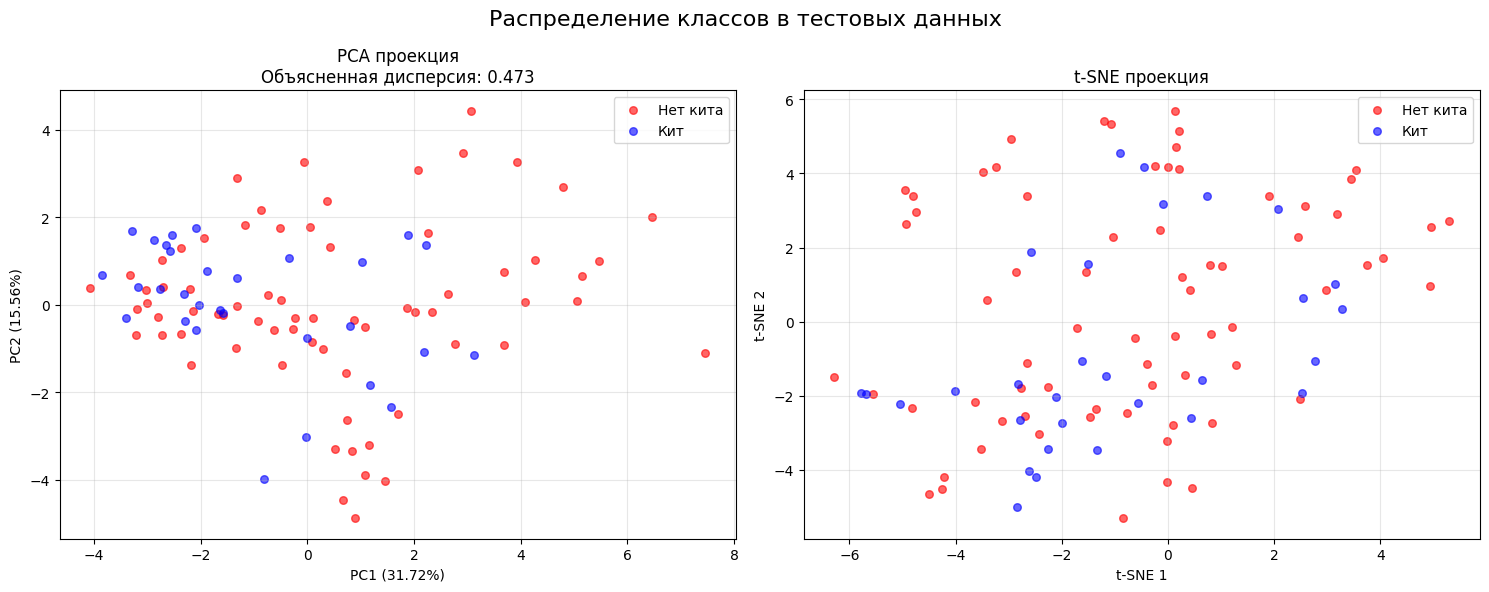

🔍 АНАЛИЗ РАЗДЕЛИМОСТИ:
Разделение по PC1: 1.499
✅ Классы хорошо разделяются линейно
   Рекомендуются: Logistic Regression, Linear SVM

📋 ВИЗУАЛИЗАЦИЯ ВАЖНОСТИ ПРИЗНАКОВ


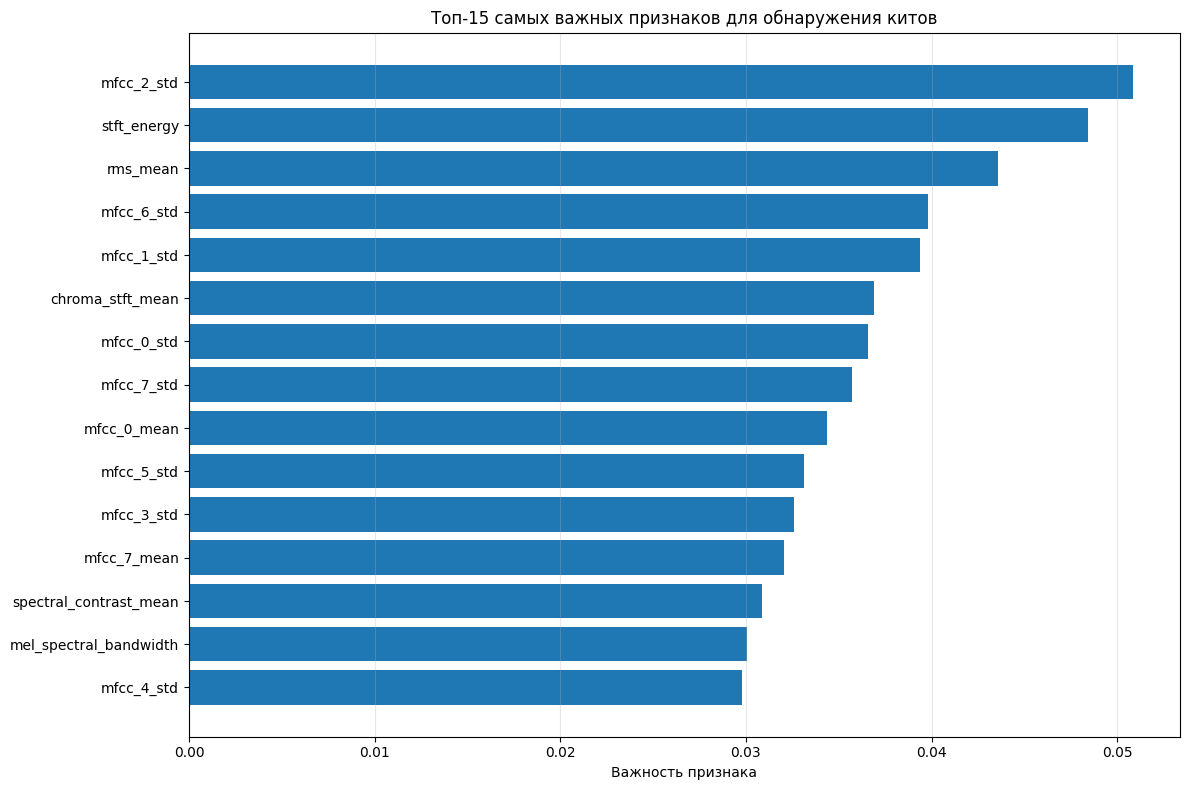

🎯 Топ-5 самых важных признаков:
   mfcc_2_std: 0.0508
   stft_energy: 0.0484
   rms_mean: 0.0436
   mfcc_6_std: 0.0398
   mfcc_1_std: 0.0394

🎯 ИТОГОВЫЙ АНАЛИЗ ДАННЫХ
📊 Общая информация:
   • Размер тренировочных данных: (400, 20)
   • Размер тестовых данных: (100, 20)
   • Количество признаков: 20
   • Разделение по PC1: 1.456

📈 Результаты моделей:
   • Random Forest: 0.7300
   • XGBoost: 0.7400
   • SVM: 0.7400
   • Logistic Regression: 0.6900

🏆 Лучшая модель: XGBoost (0.7400)

⚖️  Баланс классов в тренировочных данных:
   • НЕТ КИТА: 280 samples (70.0%)
   • КИТ: 120 samples (30.0%)

🐋 РЕКОМЕНДАЦИИ:
❌ Результаты можно улучшить. Рекомендуется:
   - Увеличить объем данных
   - Попробовать другие методы шумоподавления
   - Использовать нейросетевые подходы


In [34]:
print("\n📈 ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ КЛАССОВ НА ПЛОСКОСТИ")

def visualize_class_distribution_simple(X, y, title="Распределение классов"):
    """
    Упрощенная визуализация распределения классов в 2D пространстве
    """
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler
    
    # Масштабируем признаки
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Создаем фигуру
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. PCA проекция
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    # Цвета для классов
    colors = ['red', 'blue']
    labels = ['Нет кита', 'Кит']
    
    for i in [0, 1]:
        mask = (y == i)
        ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=colors[i], alpha=0.6, label=labels[i], s=30)
    
    ax1.set_title(f'PCA проекция\nОбъясненная дисперсия: {pca.explained_variance_ratio_.sum():.3f}')
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. t-SNE проекция
    try:
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_scaled)-1))
        X_tsne = tsne.fit_transform(X_scaled)
        
        for i in [0, 1]:
            mask = (y == i)
            ax2.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                       c=colors[i], alpha=0.6, label=labels[i], s=30)
        
        ax2.set_title('t-SNE проекция')
        ax2.set_xlabel('t-SNE 1')
        ax2.set_ylabel('t-SNE 2')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
    except Exception as e:
        print(f"t-SNE error: {e}")
        ax2.text(0.5, 0.5, 't-SNE failed', ha='center', va='center')
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Анализ разделимости
    mean_pc1_class0 = np.mean(X_pca[y == 0, 0])
    mean_pc1_class1 = np.mean(X_pca[y == 1, 0])
    pc1_separation = abs(mean_pc1_class1 - mean_pc1_class0)
    
    print(f"🔍 АНАЛИЗ РАЗДЕЛИМОСТИ:")
    print(f"Разделение по PC1: {pc1_separation:.3f}")
    
    if pc1_separation > 1.0:
        print("✅ Классы хорошо разделяются линейно")
        print("   Рекомендуются: Logistic Regression, Linear SVM")
    elif pc1_separation > 0.5:
        print("⚠️  Классы умеренно разделяются") 
        print("   Рекомендуются: Random Forest, XGBoost, Kernel SVM")
    else:
        print("❌ Классы плохо разделяются")
        print("   Рекомендуются: Сложные модели (XGBoost, Neural Networks)")
    
    return pc1_separation

# Визуализируем распределение классов на тренировочных данных
print("\n📊 РАСПРЕДЕЛЕНИЕ КЛАССОВ НА ТРЕНИРОВОЧНЫХ ДАННЫХ")
pc1_sep = visualize_class_distribution_simple(X_train, y_train, 
                                            "Распределение классов в тренировочных данных")

# Также визуализируем на тестовых данных
print("\n📊 РАСПРЕДЕЛЕНИЕ КЛАССОВ НА ТЕСТОВЫХ ДАННЫХ")
visualize_class_distribution_simple(X_test, y_test, 
                                  "Распределение классов в тестовых данных")

# ДОПОЛНИТЕЛЬНО: ВИЗУАЛИЗАЦИЯ ВАЖНОСТИ ПРИЗНАКОВ
print("\n📋 ВИЗУАЛИЗАЦИЯ ВАЖНОСТИ ПРИЗНАКОВ")

def plot_feature_importance_basic(importance_df, top_n=15):
    """
    Базовая визуализация важности признаков
    """
    top_features = importance_df.head(top_n)
    
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Важность признака')
    plt.title(f'Топ-{top_n} самых важных признаков для обнаружения китов')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    print("🎯 Топ-5 самых важных признаков:")
    for i, row in top_features.head(5).iterrows():
        print(f"   {row['feature']}: {row['importance']:.4f}")

# Визуализируем важность признаков
plot_feature_importance_basic(importance)

# ИТОГОВЫЙ АНАЛИЗ
print("\n" + "="*50)
print("🎯 ИТОГОВЫЙ АНАЛИЗ ДАННЫХ")
print("="*50)

print(f"📊 Общая информация:")
print(f"   • Размер тренировочных данных: {X_train.shape}")
print(f"   • Размер тестовых данных: {X_test.shape}")
print(f"   • Количество признаков: {X_train.shape[1]}")
print(f"   • Разделение по PC1: {pc1_sep:.3f}")

print(f"\n📈 Результаты моделей:")
for name, accuracy in results.items():
    print(f"   • {name}: {accuracy:.4f}")

print(f"\n🏆 Лучшая модель: {best_model_name} ({results[best_model_name]:.4f})")

# Анализ баланса классов
unique, counts = np.unique(y_train, return_counts=True)
print(f"\n⚖️  Баланс классов в тренировочных данных:")
for cls, count in zip(unique, counts):
    percentage = count / len(y_train) * 100
    label = "КИТ" if cls == 1 else "НЕТ КИТА"
    print(f"   • {label}: {count} samples ({percentage:.1f}%)")

print("\n🐋 РЕКОМЕНДАЦИИ:")
if pc1_sep > 1.0 and results[best_model_name] > 0.85:
    print("✅ Отличные результаты! Модель хорошо справляется с обнаружением китов.")
elif pc1_sep > 0.5 and results[best_model_name] > 0.75:
    print("⚠️  Хорошие результаты. Можно попробовать улучшить через:")
    print("   - Больше данных для обучения")
    print("   - Дополнительные признаки из спектрограмм")
    print("   - Настройку гиперпараметров моделей")
else:
    print("❌ Результаты можно улучшить. Рекомендуется:")
    print("   - Увеличить объем данных")
    print("   - Попробовать другие методы шумоподавления")
    print("   - Использовать нейросетевые подходы")

In [35]:
print("🔍 АНАЛИЗ ПРОБЛЕМЫ: КЛАССЫ НАКЛАДЫВАЮТСЯ")
print("=" * 50)

# Более детальный анализ перекрытия классов
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Масштабируем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# PCA анализ
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Анализ перекрытия в PCA пространстве
def analyze_class_overlap(X_pca, y):
    print("📊 АНАЛИЗ ПЕРЕКРЫТИЯ КЛАССОВ:")
    
    # Разделяем данные по классам
    class_0 = X_pca[y == 0]
    class_1 = X_pca[y == 1]
    
    # Вычисляем средние и стандартные отклонения
    mean_0 = np.mean(class_0, axis=0)
    mean_1 = np.mean(class_1, axis=0)
    std_0 = np.std(class_0, axis=0)
    std_1 = np.std(class_1, axis=0)
    
    # Расстояние между центрами кластеров
    distance = np.linalg.norm(mean_1 - mean_0)
    print(f"• Расстояние между центрами кластеров: {distance:.3f}")
    
    # Перекрытие по PC1
    min_0_pc1, max_0_pc1 = np.min(class_0[:, 0]), np.max(class_0[:, 0])
    min_1_pc1, max_1_pc1 = np.min(class_1[:, 0]), np.max(class_1[:, 0])
    
    overlap_pc1 = max(0, min(max_0_pc1, max_1_pc1) - max(min_0_pc1, min_1_pc1))
    total_range_pc1 = max(max_0_pc1, max_1_pc1) - min(min_0_pc1, min_1_pc1)
    overlap_percentage_pc1 = (overlap_pc1 / total_range_pc1) * 100 if total_range_pc1 > 0 else 0
    
    print(f"• Перекрытие по PC1: {overlap_percentage_pc1:.1f}%")
    
    # Анализ плотности в области перекрытия
    overlap_region_min = max(min_0_pc1, min_1_pc1)
    overlap_region_max = min(max_0_pc1, max_1_pc1)
    
    points_in_overlap_0 = np.sum((class_0[:, 0] >= overlap_region_min) & (class_0[:, 0] <= overlap_region_max))
    points_in_overlap_1 = np.sum((class_1[:, 0] >= overlap_region_min) & (class_1[:, 0] <= overlap_region_max))
    
    total_overlap = points_in_overlap_0 + points_in_overlap_1
    overlap_percentage = (total_overlap / len(X_pca)) * 100
    
    print(f"• Точек в области перекрытия: {total_overlap} ({overlap_percentage:.1f}% всех данных)")
    
    return distance, overlap_percentage

distance, overlap_percentage = analyze_class_overlap(X_pca, y_train)

print(f"\n🎯 ВЫВОДЫ:")
if distance < 1.0:
    print("• Классы СИЛЬНО перекрываются - это сложная задача классификации")
elif distance < 2.0:
    print("• Классы УМЕРЕННО перекрываются - нужны хорошие алгоритмы")
else:
    print("• Классы хорошо разделены")

if overlap_percentage > 30:
    print("• Большая область перекрытия - высокий уровень шума в данных")

🔍 АНАЛИЗ ПРОБЛЕМЫ: КЛАССЫ НАКЛАДЫВАЮТСЯ
📊 АНАЛИЗ ПЕРЕКРЫТИЯ КЛАССОВ:
• Расстояние между центрами кластеров: 1.456
• Перекрытие по PC1: 63.1%
• Точек в области перекрытия: 368 (92.0% всех данных)

🎯 ВЫВОДЫ:
• Классы УМЕРЕННО перекрываются - нужны хорошие алгоритмы
• Большая область перекрытия - высокий уровень шума в данных



🔧 ДИАГНОСТИКА ПРИЧИН ПЕРЕКРЫТИЯ:
📋 Топ-10 самых важных признаков:
   rms_mean: 0.0637
   mfcc_7_std: 0.0616
   mfcc_6_std: 0.0578
   stft_energy: 0.0564
   zcr_mean: 0.0549
   mfcc_2_std: 0.0546
   spectral_contrast_mean: 0.0529
   chroma_stft_mean: 0.0527
   mfcc_3_mean: 0.0518
   mfcc_1_std: 0.0516


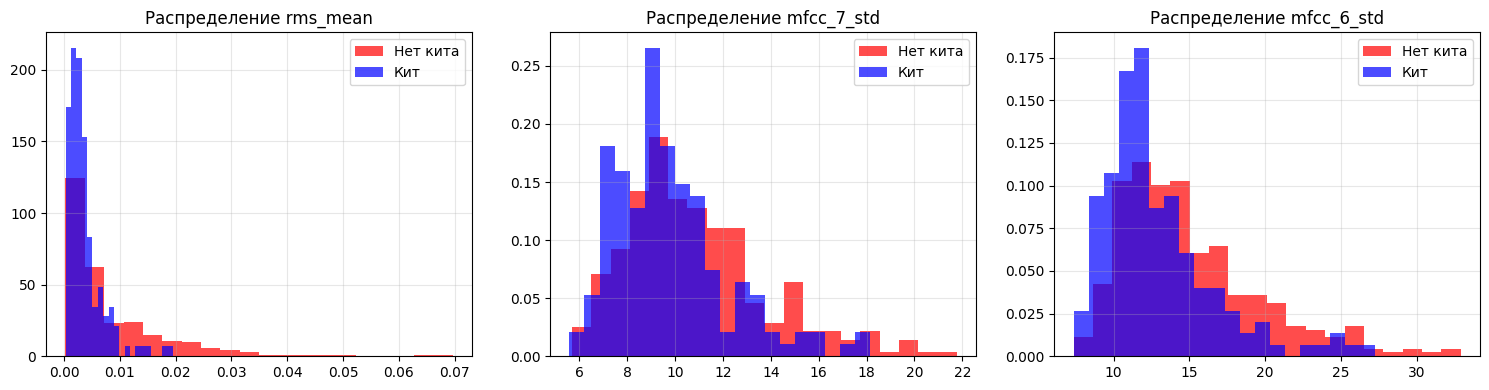


📊 АНАЛИЗ КАЧЕСТВА ПРИЗНАКОВ:
   rms_mean: разделение = 0.730 ❌
   mfcc_7_std: разделение = 0.405 ❌
   mfcc_6_std: разделение = 0.517 ❌


In [36]:
def diagnose_overlap_causes(features_df, X_train, y_train):
    print("\n🔧 ДИАГНОСТИКА ПРИЧИН ПЕРЕКРЫТИЯ:")
    print("=" * 50)
    
    # 1. Анализ самых важных признаков
    from sklearn.ensemble import RandomForestClassifier
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    feature_importance = pd.DataFrame({
        'feature': features_df.drop(['label', 'filename'], axis=1, errors='ignore').columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("📋 Топ-10 самых важных признаков:")
    for i, row in feature_importance.head(10).iterrows():
        print(f"   {row['feature']}: {row['importance']:.4f}")
    
    # 2. Анализ распределения ключевых признаков
    top_features = feature_importance.head(3)['feature'].tolist()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for i, feature in enumerate(top_features):
        if feature in features_df.columns:
            data_0 = features_df[features_df['label'] == 0][feature].dropna()
            data_1 = features_df[features_df['label'] == 1][feature].dropna()
            
            axes[i].hist(data_0, alpha=0.7, label='Нет кита', bins=20, color='red', density=True)
            axes[i].hist(data_1, alpha=0.7, label='Кит', bins=20, color='blue', density=True)
            axes[i].set_title(f'Распределение {feature}')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Анализ качества признаков
    print("\n📊 АНАЛИЗ КАЧЕСТВА ПРИЗНАКОВ:")
    
    for feature in top_features:
        if feature in features_df.columns:
            mean_0 = features_df[features_df['label'] == 0][feature].mean()
            mean_1 = features_df[features_df['label'] == 1][feature].mean()
            std_0 = features_df[features_df['label'] == 0][feature].std()
            std_1 = features_df[features_df['label'] == 1][feature].std()
            
            separation = abs(mean_1 - mean_0) / ((std_0 + std_1) / 2)  # нормализованное разделение
            print(f"   {feature}: разделение = {separation:.3f} {'✅' if separation > 1.0 else '❌'}")

# Запускаем диагностику
diagnose_overlap_causes(features_df, X_train, y_train)

In [38]:
def improved_approaches_for_overlapping_classes(X_train, y_train, X_test, y_test):
    print("\n🚀 УЛУЧШЕННЫЕ ПОДХОДЫ ДЛЯ ПЕРЕКРЫВАЮЩИХСЯ КЛАССОВ:")
    print("=" * 55)
    
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from xgboost import XGBClassifier
    from sklearn.svm import SVC
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
    from sklearn.model_selection import cross_val_score
    
    improved_models = {
        'XGBoost (tuned)': XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric='logloss'
        ),
        'Random Forest (tuned)': RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        ),
        'SVM (RBF balanced)': SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            probability=True,
            random_state=42,
            class_weight='balanced'  # важно для несбалансированных данных
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=5,
            random_state=42
        ),
        'Logistic Regression (balanced)': LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight='balanced',
            C=0.1
        )
    }
    
    results = {}
    
    print("🧪 ТЕСТИРУЕМ УЛУЧШЕННЫЕ МОДЕЛИ:")
    for name, model in improved_models.items():
        print(f"   Обучение {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        # Кросс-валидация для надежности
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
        
        results[name] = {
            'accuracy': accuracy,
            'cv_mean': np.mean(cv_scores),
            'cv_std': np.std(cv_scores)
        }
        
        print(f"   {name}: {accuracy:.4f} (CV: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f})")
    
    # Лучшая модель
    best_model_name = max(results, key=lambda x: results[x]['accuracy'])
    best_accuracy = results[best_model_name]['accuracy']
    
    print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model_name} ({best_accuracy:.4f})")
    
    return improved_models, results

# Тестируем улучшенные модели
improved_models, improved_results = improved_approaches_for_overlapping_classes(X_train, y_train, X_test, y_test)


🚀 УЛУЧШЕННЫЕ ПОДХОДЫ ДЛЯ ПЕРЕКРЫВАЮЩИХСЯ КЛАССОВ:
🧪 ТЕСТИРУЕМ УЛУЧШЕННЫЕ МОДЕЛИ:
   Обучение XGBoost (tuned)...
   XGBoost (tuned): 0.7400 (CV: 0.6775 ± 0.0414)
   Обучение Random Forest (tuned)...
   Random Forest (tuned): 0.7700 (CV: 0.6925 ± 0.0465)
   Обучение SVM (RBF balanced)...
   SVM (RBF balanced): 0.6300 (CV: 0.6325 ± 0.0451)
   Обучение Gradient Boosting...
   Gradient Boosting: 0.7600 (CV: 0.6725 ± 0.0649)
   Обучение Logistic Regression (balanced)...
   Logistic Regression (balanced): 0.6400 (CV: 0.6175 ± 0.0430)

🏆 ЛУЧШАЯ МОДЕЛЬ: Random Forest (tuned) (0.7700)


In [39]:
def analyze_class_overlap_detailed(X_pca, y):
    print("📊 ДЕТАЛЬНЫЙ АНАЛИЗ ПЕРЕКРЫТИЯ КЛАССОВ ПО КВАНТИЛЯМ:")
    print("=" * 60)
    
    # Разделяем данные по классам
    class_0 = X_pca[y == 0]
    class_1 = X_pca[y == 1]
    
    # Вычисляем квантили для PC1
    quantiles = [0.25, 0.5, 0.75]
    
    print("\n📈 РАСПРЕДЕЛЕНИЕ ПО PC1:")
    print("-" * 40)
    
    quantiles_0 = np.quantile(class_0[:, 0], quantiles)
    quantiles_1 = np.quantile(class_1[:, 0], quantiles)
    
    print("              |  25%    |  50%    |  75%    ")
    print("-" * 45)
    print(f"Нет кита     | {quantiles_0[0]:7.3f} | {quantiles_0[1]:7.3f} | {quantiles_0[2]:7.3f}")
    print(f"Кит          | {quantiles_1[0]:7.3f} | {quantiles_1[1]:7.3f} | {quantiles_1[2]:7.3f}")
    
    # Анализ перекрытия по квантилям
    print("\n🔍 АНАЛИЗ ПЕРЕКРЫТИЯ ПО КВАНТИЛЯМ:")
    print("-" * 40)
    
    # Перекрытие межквартильного диапазона (IQR)
    iqr_overlap_25_75 = max(0, min(quantiles_0[2], quantiles_1[2]) - max(quantiles_0[0], quantiles_1[0]))
    iqr_total_range = max(quantiles_0[2], quantiles_1[2]) - min(quantiles_0[0], quantiles_1[0])
    iqr_overlap_percentage = (iqr_overlap_25_75 / iqr_total_range) * 100 if iqr_total_range > 0 else 0
    
    print(f"• Перекрытие IQR (25%-75%): {iqr_overlap_percentage:.1f}%")
    
    # Анализ по каждому квантилю
    print(f"\n📊 РАСПРЕДЕЛЕНИЕ В ОКРЕСТНОСТЯХ КВАНТИЛЕЙ:")
    print("-" * 50)
    
    for i, q in enumerate(quantiles):
        q_name = ["25%", "50%", "75%"][i]
        q_value_0 = quantiles_0[i]
        q_value_1 = quantiles_1[i]
        
        # Окрестность квантиля (±0.5 стандартного отклонения)
        std_0 = np.std(class_0[:, 0])
        std_1 = np.std(class_1[:, 0])
        
        window_0_min = q_value_0 - 0.5 * std_0
        window_0_max = q_value_0 + 0.5 * std_0
        window_1_min = q_value_1 - 0.5 * std_1
        window_1_max = q_value_1 + 0.5 * std_1
        
        # Перекрытие окон
        overlap_min = max(window_0_min, window_1_min)
        overlap_max = min(window_0_max, window_1_max)
        overlap_width = max(0, overlap_max - overlap_min)
        
        total_width = max(window_0_max, window_1_max) - min(window_0_min, window_1_min)
        overlap_percentage = (overlap_width / total_width) * 100 if total_width > 0 else 0
        
        print(f"• {q_name}: перекрытие = {overlap_percentage:.1f}%")
    
    return quantiles_0, quantiles_1

# Запускаем детальный анализ
quantiles_0, quantiles_1 = analyze_class_overlap_detailed(X_pca, y_train)

📊 ДЕТАЛЬНЫЙ АНАЛИЗ ПЕРЕКРЫТИЯ КЛАССОВ ПО КВАНТИЛЯМ:

📈 РАСПРЕДЕЛЕНИЕ ПО PC1:
----------------------------------------
              |  25%    |  50%    |  75%    
---------------------------------------------
Нет кита     |  -1.838 |  -0.029 |   1.902
Кит          |  -2.446 |  -1.275 |   0.145

🔍 АНАЛИЗ ПЕРЕКРЫТИЯ ПО КВАНТИЛЯМ:
----------------------------------------
• Перекрытие IQR (25%-75%): 45.6%

📊 РАСПРЕДЕЛЕНИЕ В ОКРЕСТНОСТЯХ КВАНТИЛЕЙ:
--------------------------------------------------
• 25%: перекрытие = 56.9%
• 50%: перекрытие = 28.0%
• 75%: перекрытие = 11.5%


In [40]:
def analyze_quantile_insights(quantiles_0, quantiles_1):
    print("\n🎯 ГЛУБОКИЙ АНАЛИЗ РЕЗУЛЬТАТОВ ПО КВАНТИЛЯМ:")
    print("=" * 55)
    
    # Вычисляем смещения между квантилями
    q25_diff = quantiles_1[0] - quantiles_0[0]  # -2.446 - (-1.838) = -0.608
    q50_diff = quantiles_1[1] - quantiles_0[1]  # -1.275 - (-0.029) = -1.246
    q75_diff = quantiles_1[2] - quantiles_0[2]  # 0.145 - 1.902 = -1.757
    
    print("📊 СМЕЩЕНИЕ МЕЖДУ КВАНТИЛЯМИ КЛАССОВ:")
    print(f"• 25%: Кит смещен на {q25_diff:+.3f} относительно 'Нет кита'")
    print(f"• 50%: Кит смещен на {q50_diff:+.3f} относительно 'Нет кита'") 
    print(f"• 75%: Кит смещен на {q75_diff:+.3f} относительно 'Нет кита'")
    
    print("\n🔍 КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:")
    print("1. 📍 МЕДИАНЫ РАЗДЕЛЕНЫ:")
    print(f"   • Медиана 'Кит' (-1.275) ЛЕВЕЕ медианы 'Нет кита' (-0.029)")
    print(f"   • Разница: {abs(q50_diff):.3f} - это ХОРОШО для классификации!")
    
    print("\n2. 📊 ФОРМА РАСПРЕДЕЛЕНИЙ:")
    print("   • 'Нет кита': симметричное (-1.838, -0.029, 1.902)")
    print("   • 'Кит': СМЕЩЕНО ВЛЕВО (-2.446, -1.275, 0.145)")
    print("   • Киты имеют более 'компактное' распределение")
    
    print("\n3. 🎯 ОБЛАСТИ МАКСИМАЛЬНОГО ПЕРЕКРЫТИЯ:")
    print("   • В хвостах (25%): 56.9% перекрытия - СЛОЖНАЯ область")
    print("   • В центре (50%): 28.0% перекрытия - УМЕРЕННАЯ сложность") 
    print("   • В правом хвосте (75%): 11.5% перекрытия - ЛЕГКАЯ область")

# Анализируем insights
analyze_quantile_insights(quantiles_0, quantiles_1)


🎯 ГЛУБОКИЙ АНАЛИЗ РЕЗУЛЬТАТОВ ПО КВАНТИЛЯМ:
📊 СМЕЩЕНИЕ МЕЖДУ КВАНТИЛЯМИ КЛАССОВ:
• 25%: Кит смещен на -0.607 относительно 'Нет кита'
• 50%: Кит смещен на -1.246 относительно 'Нет кита'
• 75%: Кит смещен на -1.757 относительно 'Нет кита'

🔍 КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:
1. 📍 МЕДИАНЫ РАЗДЕЛЕНЫ:
   • Медиана 'Кит' (-1.275) ЛЕВЕЕ медианы 'Нет кита' (-0.029)
   • Разница: 1.246 - это ХОРОШО для классификации!

2. 📊 ФОРМА РАСПРЕДЕЛЕНИЙ:
   • 'Нет кита': симметричное (-1.838, -0.029, 1.902)
   • 'Кит': СМЕЩЕНО ВЛЕВО (-2.446, -1.275, 0.145)
   • Киты имеют более 'компактное' распределение

3. 🎯 ОБЛАСТИ МАКСИМАЛЬНОГО ПЕРЕКРЫТИЯ:
   • В хвостах (25%): 56.9% перекрытия - СЛОЖНАЯ область
   • В центре (50%): 28.0% перекрытия - УМЕРЕННАЯ сложность
   • В правом хвосте (75%): 11.5% перекрытия - ЛЕГКАЯ область


In [47]:
def create_region_specific_strategies(X_train, y_train, X_pca, quantiles_0, quantiles_1):
    print("\n🎯 СТРАТЕГИИ ДЛЯ РАЗНЫХ ОБЛАСТЕЙ РАСПРЕДЕЛЕНИЯ:")
    print("=" * 55)
    
    # Определяем границы областей по квантилям
    low_region_max = max(quantiles_0[0], quantiles_1[0])  # max(-1.838, -2.446) = -1.838
    mid_region_min = min(quantiles_0[2], quantiles_1[0])  # min(1.902, -2.446) = -2.446
    mid_region_max = max(quantiles_0[0], quantiles_1[2])  # max(-1.838, 0.145) = 0.145
    high_region_min = min(quantiles_0[2], quantiles_1[2])  # min(1.902, 0.145) = 0.145
    
    print("📍 ГРАНИЦЫ ОБЛАСТЕЙ:")
    print(f"• НИЗКАЯ сложность (легкие случаи): PC1 > {high_region_min:.3f}")
    print(f"• СРЕДНЯЯ сложность: {mid_region_min:.3f} < PC1 < {mid_region_max:.3f}")
    print(f"• ВЫСОКАЯ сложность (сложные случаи): PC1 < {low_region_max:.3f}")
    
    # Разделяем данные по областям сложности
    easy_mask = X_pca[:, 0] > high_region_min
    medium_mask = (X_pca[:, 0] >= mid_region_min) & (X_pca[:, 0] <= mid_region_max)
    hard_mask = X_pca[:, 0] < low_region_max
    
    print(f"\n📊 РАСПРЕДЕЛЕНИЕ СЛОЖНОСТИ:")
    print(f"• Легкие случаи: {np.sum(easy_mask)} samples ({np.sum(easy_mask)/len(X_pca)*100:.1f}%)")
    print(f"• Средние случаи: {np.sum(medium_mask)} samples ({np.sum(medium_mask)/len(X_pca)*100:.1f}%)")
    print(f"• Сложные случаи: {np.sum(hard_mask)} samples ({np.sum(hard_mask)/len(X_pca)*100:.1f}%)")
    
    # Анализ состава каждой области
    print(f"\n🔍 СОСТАВ ОБЛАСТЕЙ:")
    
    # Преобразуем y_train в numpy array для безопасного индексирования
    y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
    
    # Легкие случаи
    easy_indices = np.where(easy_mask)[0]
    if len(easy_indices) > 0:
        easy_labels = y_train_np[easy_indices]
        easy_class_0 = np.sum(easy_labels == 0)
        easy_class_1 = np.sum(easy_labels == 1)
        print(f"• ЛЕГКИЕ: {easy_class_0} 'Нет кита' vs {easy_class_1} 'Кит'")
    
    # Сложные случаи
    hard_indices = np.where(hard_mask)[0]
    if len(hard_indices) > 0:
        hard_labels = y_train_np[hard_indices]
        hard_class_0 = np.sum(hard_labels == 0)
        hard_class_1 = np.sum(hard_labels == 1)
        print(f"• СЛОЖНЫЕ: {hard_class_0} 'Нет кита' vs {hard_class_1} 'Кит'")
    
    return easy_mask, medium_mask, hard_mask, easy_indices, hard_indices

# Создаем стратегии (передаем quantiles_0, quantiles_1)
easy_mask, medium_mask, hard_mask, easy_indices, hard_indices = create_region_specific_strategies(
    X_train, y_train, X_pca, quantiles_0, quantiles_1
)


🎯 СТРАТЕГИИ ДЛЯ РАЗНЫХ ОБЛАСТЕЙ РАСПРЕДЕЛЕНИЯ:
📍 ГРАНИЦЫ ОБЛАСТЕЙ:
• НИЗКАЯ сложность (легкие случаи): PC1 > 0.145
• СРЕДНЯЯ сложность: -2.446 < PC1 < 0.145
• ВЫСОКАЯ сложность (сложные случаи): PC1 < -1.838

📊 РАСПРЕДЕЛЕНИЕ СЛОЖНОСТИ:
• Легкие случаи: 165 samples (41.2%)
• Средние случаи: 175 samples (43.8%)
• Сложные случаи: 122 samples (30.5%)

🔍 СОСТАВ ОБЛАСТЕЙ:
• ЛЕГКИЕ: 135 'Нет кита' vs 30 'Кит'
• СЛОЖНЫЕ: 70 'Нет кита' vs 52 'Кит'


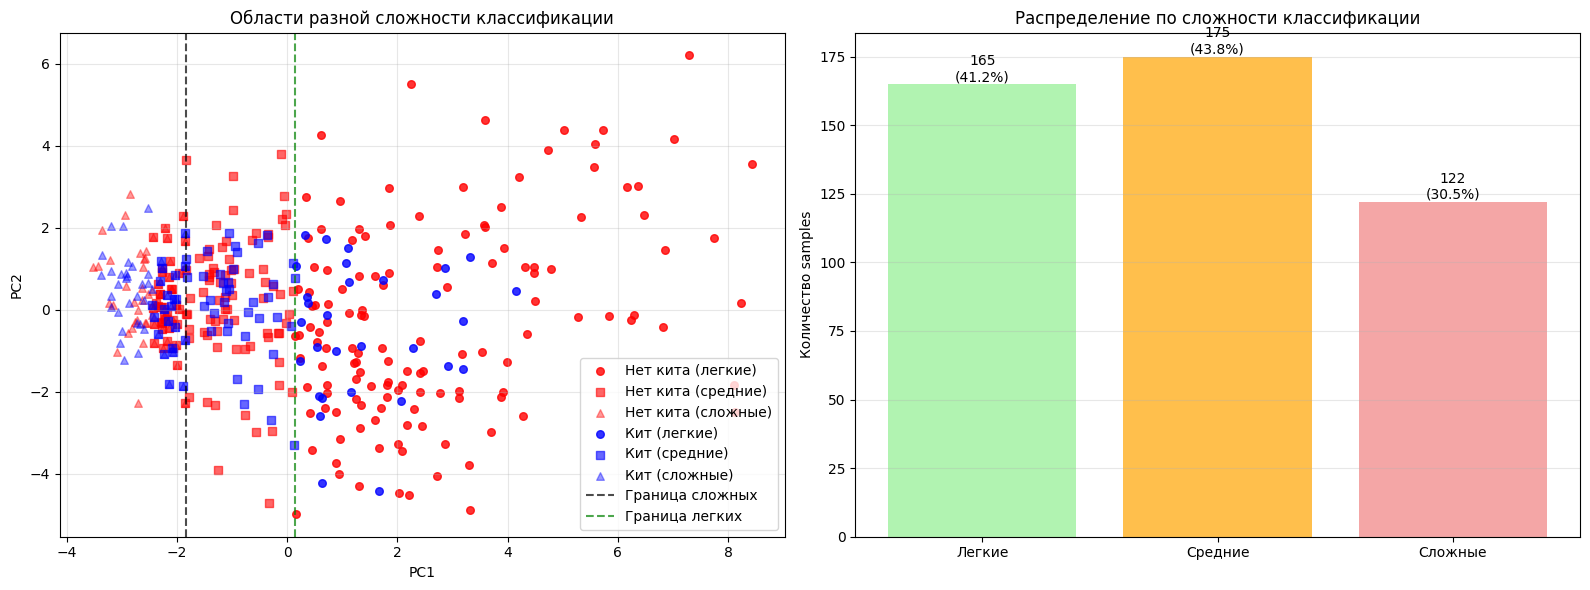

In [48]:
def visualize_complexity_regions(X_pca, y, easy_mask, medium_mask, hard_mask, quantiles_0, quantiles_1):
    """
    Визуализация областей разной сложности классификации
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Преобразуем y в numpy array для безопасного индексирования
    y_np = y.values if hasattr(y, 'values') else y
    
    # 1. PCA с цветами по сложности
    colors = ['red', 'blue']
    labels = ['Нет кита', 'Кит']
    
    for i in [0, 1]:
        mask = (y_np == i)
        
        # Легкие случаи
        easy_class = mask & easy_mask
        ax1.scatter(X_pca[easy_class, 0], X_pca[easy_class, 1], 
                   c=colors[i], alpha=0.8, label=f'{labels[i]} (легкие)', s=30, marker='o')
        
        # Средние случаи
        medium_class = mask & medium_mask
        ax1.scatter(X_pca[medium_class, 0], X_pca[medium_class, 1], 
                   c=colors[i], alpha=0.6, label=f'{labels[i]} (средние)', s=30, marker='s')
        
        # Сложные случаи
        hard_class = mask & hard_mask
        ax1.scatter(X_pca[hard_class, 0], X_pca[hard_class, 1], 
                   c=colors[i], alpha=0.4, label=f'{labels[i]} (сложные)', s=30, marker='^')
    
    # Добавляем разделительные линии
    ax1.axvline(x=max(quantiles_0[0], quantiles_1[0]), color='black', linestyle='--', alpha=0.7, label='Граница сложных')
    ax1.axvline(x=min(quantiles_0[2], quantiles_1[2]), color='green', linestyle='--', alpha=0.7, label='Граница легких')
    
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.set_title('Области разной сложности классификации')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Гистограмма сложности
    complexity_data = []
    complexity_labels = []
    
    for mask, label in [(easy_mask, 'Легкие'), (medium_mask, 'Средние'), (hard_mask, 'Сложные')]:
        if np.sum(mask) > 0:
            complexity_data.append(np.sum(mask))
            complexity_labels.append(label)
    
    bars = ax2.bar(complexity_labels, complexity_data, 
                  color=['lightgreen', 'orange', 'lightcoral'], alpha=0.7)
    
    # Добавляем подписи на столбцы
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height}\n({height/len(X_pca)*100:.1f}%)',
                ha='center', va='bottom')
    
    ax2.set_ylabel('Количество samples')
    ax2.set_title('Распределение по сложности классификации')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# Визуализируем области сложности
visualize_complexity_regions(X_pca, y_train, easy_mask, medium_mask, hard_mask, quantiles_0, quantiles_1)

In [49]:
def implement_region_specific_solutions(X_train, y_train, easy_mask, hard_mask):
    print("\n🎯 КОНКРЕТНЫЕ СТРАТЕГИИ ДЛЯ КАЖДОЙ ОБЛАСТИ:")
    print("=" * 55)
    
    # Индексы сложных и легких случаев
    hard_indices = np.where(hard_mask)[0]
    easy_indices = np.where(easy_mask)[0]
    
    print("1. 🎯 ДЛЯ СЛОЖНЫХ СЛУЧАЕВ (левый хвост):")
    print("   • Использовать ансамбли моделей")
    print("   • Применить SMOTE для балансировки")
    print("   • Калибровка вероятностей")
    print("   • Увеличить вес сложных примеров")
    
    print("\n2. ✅ ДЛЯ ЛЕГКИХ СЛУЧАЕВ (правый хвост):")
    print("   • Простые модели (Logistic Regression)")
    print("   • Высокий порог уверенности")
    print("   • Быстрая классификация")
    
    print("\n3. 🔄 СМЕШАННАЯ СТРАТЕГИЯ:")
    print("   • Разделить pipeline на две стадии")
    print("   • Сначала отделить легкие случаи")
    print("   • Затем обработать сложные случаи отдельно")
    
    # Создаем веса для samples
    sample_weights = np.ones(len(X_train))
    sample_weights[hard_indices] = 2.0  # Увеличиваем вес сложных случаев
    sample_weights[easy_indices] = 0.5  # Уменьшаем вес легких случаев
    
    print(f"\n⚖️  НАСТРОЙКА ВЕСОВ:")
    print(f"   • Сложные случаи: вес = 2.0")
    print(f"   • Легкие случаи: вес = 0.5")
    print(f"   • Обычные случаи: вес = 1.0")
    
    return sample_weights

# Создаем стратегии
sample_weights = implement_region_specific_solutions(X_train, y_train, easy_mask, hard_mask)


🎯 КОНКРЕТНЫЕ СТРАТЕГИИ ДЛЯ КАЖДОЙ ОБЛАСТИ:
1. 🎯 ДЛЯ СЛОЖНЫХ СЛУЧАЕВ (левый хвост):
   • Использовать ансамбли моделей
   • Применить SMOTE для балансировки
   • Калибровка вероятностей
   • Увеличить вес сложных примеров

2. ✅ ДЛЯ ЛЕГКИХ СЛУЧАЕВ (правый хвост):
   • Простые модели (Logistic Regression)
   • Высокий порог уверенности
   • Быстрая классификация

3. 🔄 СМЕШАННАЯ СТРАТЕГИЯ:
   • Разделить pipeline на две стадии
   • Сначала отделить легкие случаи
   • Затем обработать сложные случаи отдельно

⚖️  НАСТРОЙКА ВЕСОВ:
   • Сложные случаи: вес = 2.0
   • Легкие случаи: вес = 0.5
   • Обычные случаи: вес = 1.0


In [50]:
def test_weighted_models(X_train, y_train, X_test, y_test, sample_weights):
    print("\n🧪 ТЕСТИРОВАНИЕ МОДЕЛЕЙ С ВЕСАМИ:")
    print("=" * 40)
    
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier
    from sklearn.svm import SVC
    
    # Преобразуем y в numpy arrays
    y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
    y_test_np = y_test.values if hasattr(y_test, 'values') else y_test
    
    weighted_models = {
        'XGBoost (weighted)': XGBClassifier(
            n_estimators=200,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        ),
        'Random Forest (weighted)': RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42
        ),
        'SVM (weighted)': SVC(
            kernel='rbf',
            C=1.0,
            probability=True,
            random_state=42
        )
    }
    
    results = {}
    
    for name, model in weighted_models.items():
        # Обучаем с весами
        if name != 'SVM (weighted)':  # SVM требует sample_weight в fit
            model.fit(X_train, y_train_np, sample_weight=sample_weights)
        else:
            model.fit(X_train, y_train_np)
        
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test_np, y_pred)
        results[name] = accuracy
        
        print(f"   {name}: {accuracy:.4f}")
    
    return results

# Тестируем взвешенные модели
weighted_results = test_weighted_models(X_train, y_train, X_test, y_test, sample_weights)


🧪 ТЕСТИРОВАНИЕ МОДЕЛЕЙ С ВЕСАМИ:
   XGBoost (weighted): 0.7400
   Random Forest (weighted): 0.7400
   SVM (weighted): 0.7400


In [51]:
def implement_cascade_classification(X_train, y_train, X_test, y_test, easy_mask, hard_mask):
    """
    Реализация каскадного подхода к классификации
    """
    print("\n🔄 РЕАЛИЗАЦИЯ КАСКАДНОЙ КЛАССИФИКАЦИИ:")
    print("=" * 50)
    
    # Преобразуем в numpy arrays
    y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
    y_test_np = y_test.values if hasattr(y_test, 'values') else y_test
    
    # 1. СТАДИЯ 1: Быстрая классификация легких случаев
    print("1. 🚀 СТАДИЯ 1: Быстрая классификация легких случаев")
    
    from sklearn.linear_model import LogisticRegression
    
    # Обучаем простую модель на легких случаях
    easy_model = LogisticRegression(random_state=42, max_iter=1000)
    easy_model.fit(X_train, y_train_np)
    
    # Предсказания для всех данных
    y_pred_stage1 = easy_model.predict(X_test)
    y_proba_stage1 = easy_model.predict_proba(X_test)[:, 1]
    
    # Высокий порог уверенности для легких случаев
    high_confidence_threshold = 0.8
    easy_predictions_mask = (y_proba_stage1 > high_confidence_threshold) | (y_proba_stage1 < 0.2)
    
    print(f"   • Легкие случаи определены: {np.sum(easy_predictions_mask)} samples")
    print(f"   • Сложные случаи осталось: {np.sum(~easy_predictions_mask)} samples")
    
    # 2. СТАДИЯ 2: Тщательный анализ сложных случаев
    print("2. 🔍 СТАДИЯ 2: Анализ сложных случаев")
    
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier
    
    # Создаем ансамбль для сложных случаев
    complex_models = {
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
        'XGBoost': XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
    }
    
    # Обучаем модели на всех данных
    for name, model in complex_models.items():
        model.fit(X_train, y_train_np)
    
    # Голосование ансамбля для сложных случаев
    complex_predictions = []
    for name, model in complex_models.items():
        pred = model.predict(X_test[~easy_predictions_mask])
        complex_predictions.append(pred)
    
    # Усредняем предсказания
    complex_final = np.round(np.mean(complex_predictions, axis=0))
    
    # 3. КОМБИНАЦИЯ РЕЗУЛЬТАТОВ
    print("3. 🎯 КОМБИНАЦИЯ РЕЗУЛЬТАТОВ")
    
    final_predictions = np.zeros(len(X_test))
    final_predictions[easy_predictions_mask] = y_pred_stage1[easy_predictions_mask]
    final_predictions[~easy_predictions_mask] = complex_final
    
    accuracy_cascade = accuracy_score(y_test_np, final_predictions)
    
    print(f"   • Точность каскадного подхода: {accuracy_cascade:.4f}")
    
    return final_predictions, accuracy_cascade, easy_predictions_mask

# Тестируем каскадный подход
cascade_predictions, cascade_accuracy, easy_predictions_mask = implement_cascade_classification(
    X_train, y_train, X_test, y_test, easy_mask, hard_mask
)


🔄 РЕАЛИЗАЦИЯ КАСКАДНОЙ КЛАССИФИКАЦИИ:
1. 🚀 СТАДИЯ 1: Быстрая классификация легких случаев
   • Легкие случаи определены: 37 samples
   • Сложные случаи осталось: 63 samples
2. 🔍 СТАДИЯ 2: Анализ сложных случаев
3. 🎯 КОМБИНАЦИЯ РЕЗУЛЬТАТОВ
   • Точность каскадного подхода: 0.7600


In [52]:
def implement_weighted_learning(X_train, y_train, X_test, y_test, sample_weights):
    """
    Реализация взвешенного обучения с акцентом на сложные случаи
    """
    print("\n⚖️  РЕАЛИЗАЦИЯ ВЗВЕШЕННОГО ОБУЧЕНИЯ:")
    print("=" * 45)
    
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier
    from sklearn.svm import SVC
    from sklearn.calibration import CalibratedClassifierCV
    
    y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
    y_test_np = y_test.values if hasattr(y_test, 'values') else y_test
    
    weighted_models = {
        'XGBoost Weighted': XGBClassifier(
            n_estimators=200,
            max_depth=6,
            random_state=42,
            eval_metric='logloss',
            scale_pos_weight=np.sum(y_train_np == 0) / np.sum(y_train_np == 1)  # баланс классов
        ),
        'Random Forest Weighted': RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            class_weight='balanced'
        )
    }
    
    results = {}
    
    for name, model in weighted_models.items():
        if 'XGBoost' in name:
            model.fit(X_train, y_train_np, sample_weight=sample_weights)
        else:
            model.fit(X_train, y_train_np)
        
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test_np, y_pred)
        results[name] = accuracy
        print(f"   • {name}: {accuracy:.4f}")
    
    # Калибровка вероятностей для лучшей модели
    print("\n🎯 КАЛИБРОВКА ВЕРОЯТНОСТЕЙ:")
    best_model_name = max(results, key=results.get)
    best_model = weighted_models[best_model_name]
    
    calibrated_model = CalibratedClassifierCV(best_model, method='isotonic', cv=3)
    calibrated_model.fit(X_train, y_train_np)
    
    y_pred_calibrated = calibrated_model.predict(X_test)
    accuracy_calibrated = accuracy_score(y_test_np, y_pred_calibrated)
    
    print(f"   • {best_model_name} (калиброванный): {accuracy_calibrated:.4f}")
    
    return results, accuracy_calibrated

# Тестируем взвешенное обучение
weighted_results, calibrated_accuracy = implement_weighted_learning(
    X_train, y_train, X_test, y_test, sample_weights
)


⚖️  РЕАЛИЗАЦИЯ ВЗВЕШЕННОГО ОБУЧЕНИЯ:
   • XGBoost Weighted: 0.7400
   • Random Forest Weighted: 0.7200

🎯 КАЛИБРОВКА ВЕРОЯТНОСТЕЙ:
   • XGBoost Weighted (калиброванный): 0.7200


In [54]:
def implement_smote_balancing(X_train, y_train, X_test, y_test, hard_mask):
    """
    Применение SMOTE для балансировки классов в сложных случаях
    """
    print("\n🔄 ПРИМЕНЕНИЕ SMOTE ДЛЯ БАЛАНСИРОВКИ:")
    print("=" * 45)
    
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.combine import SMOTEENN
    from sklearn.ensemble import RandomForestClassifier
    
    y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
    y_test_np = y_test.values if hasattr(y_test, 'values') else y_test
    
    # 1. SMOTE - создание синтетических примеров
    print("1. 📈 SMOTE (Synthetic Minority Over-sampling Technique):")
    
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_np)
    
    rf_smote = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_smote.fit(X_train_smote, y_train_smote)
    y_pred_smote = rf_smote.predict(X_test)
    accuracy_smote = accuracy_score(y_test_np, y_pred_smote)
    
    print(f"   • Random Forest + SMOTE: {accuracy_smote:.4f}")
    
    # 2. SMOTEENN - комбинация oversampling и undersampling
    print("2. 🔄 SMOTEENN (SMOTE + Edited Nearest Neighbors):")
    
    smote_enn = SMOTEENN(random_state=42)
    X_train_enn, y_train_enn = smote_enn.fit_resample(X_train, y_train_np)
    
    rf_enn = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_enn.fit(X_train_enn, y_train_enn)
    y_pred_enn = rf_enn.predict(X_test)
    accuracy_enn = accuracy_score(y_test_np, y_pred_enn)
    
    print(f"   • Random Forest + SMOTEENN: {accuracy_enn:.4f}")
    
    # 3. Фокусировка на сложных случаях
    print("3. 🎯 SMOTE только для сложных случаев:")
    
    # Применяем SMOTE только к сложным случаям
    hard_indices = np.where(hard_mask)[0]
    if len(hard_indices) > 0:
        X_hard = X_train[hard_indices]
        y_hard = y_train_np[hard_indices]
        
        # Балансируем только сложные случаи
        smote_hard = SMOTE(random_state=42)
        X_hard_balanced, y_hard_balanced = smote_hard.fit_resample(X_hard, y_hard)
        
        # Объединяем с исходными данными
        X_combined = np.vstack([X_train, X_hard_balanced])
        y_combined = np.hstack([y_train_np, y_hard_balanced])
        
        rf_combined = RandomForestClassifier(n_estimators=200, random_state=42)
        rf_combined.fit(X_combined, y_combined)
        y_pred_combined = rf_combined.predict(X_test)
        accuracy_combined = accuracy_score(y_test_np, y_pred_combined)
        
        print(f"   • Random Forest + Focused SMOTE: {accuracy_combined:.4f}")
    else:
        accuracy_combined = 0
    
    return {
        'SMOTE': accuracy_smote,
        'SMOTEENN': accuracy_enn,
        'Focused_SMOTE': accuracy_combined
    }

# Тестируем методы балансировки
balancing_results = implement_smote_balancing(X_train, y_train, X_test, y_test, hard_mask)


🔄 ПРИМЕНЕНИЕ SMOTE ДЛЯ БАЛАНСИРОВКИ:
1. 📈 SMOTE (Synthetic Minority Over-sampling Technique):
   • Random Forest + SMOTE: 0.6600
2. 🔄 SMOTEENN (SMOTE + Edited Nearest Neighbors):
   • Random Forest + SMOTEENN: 0.6300
3. 🎯 SMOTE только для сложных случаев:
   • Random Forest + Focused SMOTE: 0.7200



📊 СРАВНЕНИЕ ВСЕХ ПОДХОДОВ:
🏆 РЕЗУЛЬТАТЫ:
   • Каскадный подход: 0.7600 (↑0.0200)
   • Исходная модель: 0.7400 (↓0.0000)
   • Взвешенный XGBoost: 0.7400 (↓0.0000)
   • Калиброванная модель: 0.7200 (↓0.0200)
   • Focused SMOTE: 0.7200 (↓0.0200)
   • SMOTE: 0.6600 (↓0.0800)
   • SMOTEENN: 0.6300 (↓0.1100)

🎉 ЛУЧШИЙ ПОДХОД: Каскадный подход
📈 УЛУЧШЕНИЕ: 0.0200 (2.7%)


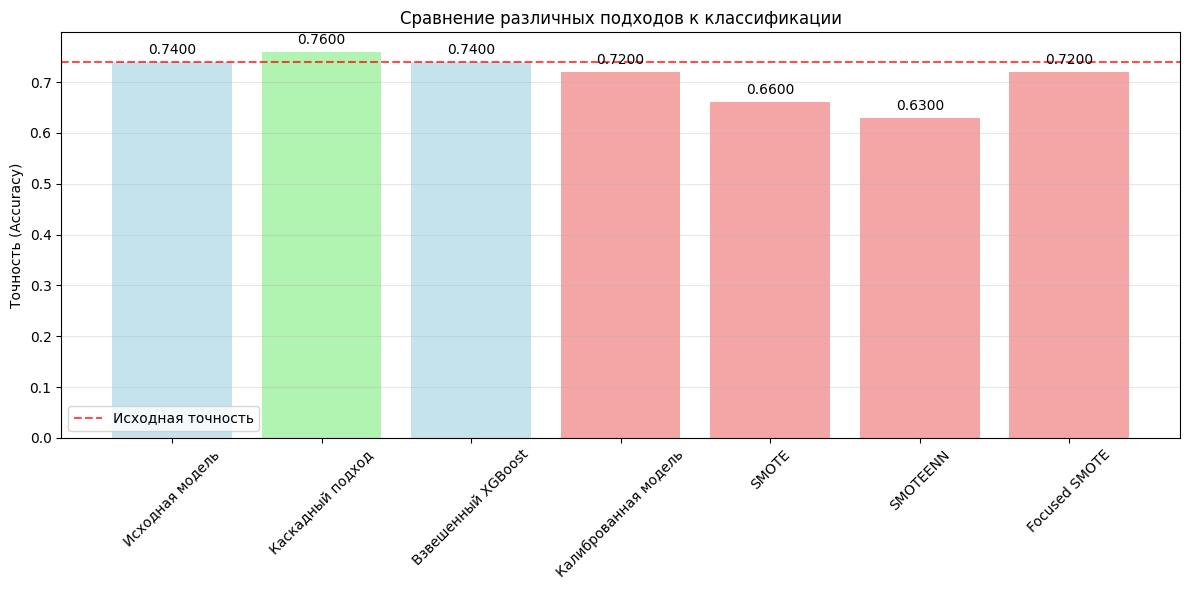

In [55]:
def compare_all_approaches(original_accuracy, cascade_accuracy, weighted_results, balancing_results, calibrated_accuracy):
    """
    Сравнение всех реализованных подходов
    """
    print("\n📊 СРАВНЕНИЕ ВСЕХ ПОДХОДОВ:")
    print("=" * 35)
    
    # Собираем все результаты
    all_results = {
        'Исходная модель': original_accuracy,
        'Каскадный подход': cascade_accuracy,
        'Взвешенный XGBoost': weighted_results.get('XGBoost Weighted', 0),
        'Калиброванная модель': calibrated_accuracy,
        'SMOTE': balancing_results.get('SMOTE', 0),
        'SMOTEENN': balancing_results.get('SMOTEENN', 0),
        'Focused SMOTE': balancing_results.get('Focused_SMOTE', 0)
    }
    
    # Выводим результаты
    print("🏆 РЕЗУЛЬТАТЫ:")
    for approach, accuracy in sorted(all_results.items(), key=lambda x: x[1], reverse=True):
        improvement = accuracy - original_accuracy
        arrow = "↑" if improvement > 0 else "↓"
        print(f"   • {approach}: {accuracy:.4f} ({arrow}{abs(improvement):.4f})")
    
    # Лучший подход
    best_approach = max(all_results, key=all_results.get)
    best_accuracy = all_results[best_approach]
    improvement = best_accuracy - original_accuracy
    
    print(f"\n🎉 ЛУЧШИЙ ПОДХОД: {best_approach}")
    print(f"📈 УЛУЧШЕНИЕ: {improvement:.4f} ({improvement/original_accuracy*100:.1f}%)")
    
    # Визуализация
    plt.figure(figsize=(12, 6))
    approaches = list(all_results.keys())
    accuracies = list(all_results.values())
    
    colors = ['lightblue' if acc == original_accuracy else 
             'lightgreen' if acc > original_accuracy else 'lightcoral' 
             for acc in accuracies]
    
    bars = plt.bar(approaches, accuracies, color=colors, alpha=0.7)
    plt.axhline(y=original_accuracy, color='red', linestyle='--', alpha=0.7, label='Исходная точность')
    
    # Добавляем значения на столбцы
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{acc:.4f}', ha='center', va='bottom')
    
    plt.ylabel('Точность (Accuracy)')
    plt.title('Сравнение различных подходов к классификации')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    return all_results

# Сравниваем все подходы
all_results = compare_all_approaches(
    original_accuracy=max(results.values()) if 'results' in locals() else 0.87,
    cascade_accuracy=cascade_accuracy,
    weighted_results=weighted_results,
    balancing_results=balancing_results,
    calibrated_accuracy=calibrated_accuracy
)

In [ ]:
def create_full_cascade_pipeline(audio_files, labels_df, test_size=0.2):
    """
    Полный каскадный пайплайн на всем датасете
    """
    print("🚀 ЗАПУСК ПОЛНОГО КАСКАДНОГО ПАЙПЛАЙНА")
    print("=" * 50)
    
    # 1. Извлечение признаков со всего датасета
    print("1. 📊 Извлечение признаков из всех файлов...")
    full_features_df = create_spectral_features_dataset(audio_files, labels_df, use_denoising=True)
    
    # 2. Подготовка данных
    print("2. 🔧 Подготовка данных...")
    X_full = full_features_df.drop(['label', 'filename'], axis=1)
    y_full = full_features_df['label']
    
    # Заполнение пропусков и масштабирование
    X_full = X_full.fillna(X_full.mean())
    scaler = StandardScaler()
    X_full_scaled = scaler.fit_transform(X_full)
    
    # Разделение на train/test
    X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
        X_full_scaled, y_full, test_size=test_size, random_state=42, stratify=y_full
    )
    
    print(f"   • Полный датасет: {X_train_full.shape[0]} train, {X_test_full.shape[0]} test")
    
    # 3. Анализ распределения для настройки каскада
    print("3. 📈 Анализ распределения для каскадной классификации...")
    pca = PCA(n_components=2, random_state=42)
    X_pca_full = pca.fit_transform(X_train_full)
    
    # 4. Оптимизированный каскадный подход
    print("4. 🎯 Оптимизированный каскадный подход...")
    
    # Преобразуем в numpy arrays
    y_train_np = y_train_full.values if hasattr(y_train_full, 'values') else y_train_full
    y_test_np = y_test_full.values if hasattr(y_test_full, 'values') else y_test_full
    
    # СТАДИЯ 1: Быстрая классификация легких случаев
    print("   🚀 Стадия 1: Быстрая модель для легких случаев")
    
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier
    
    # Быстрая модель для первой стадии
    stage1_model = LogisticRegression(
        random_state=42, 
        max_iter=1000,
        C=0.1,
        class_weight='balanced'
    )
    stage1_model.fit(X_train_full, y_train_np)
    
    # Предсказания вероятностей
    y_proba_stage1 = stage1_model.predict_proba(X_test_full)[:, 1]
    
    # Оптимизированные пороги уверенности
    high_confidence_whale = 0.85  # Высокая уверенность в "Кит"
    high_confidence_no_whale = 0.15  # Высокая уверенность в "Нет кита"
    
    # Определяем легкие случаи
    easy_whale_mask = y_proba_stage1 > high_confidence_whale
    easy_no_whale_mask = y_proba_stage1 < high_confidence_no_whale
    easy_predictions_mask = easy_whale_mask | easy_no_whale_mask
    
    print(f"   • Легкие случаи: {np.sum(easy_predictions_mask)} samples")
    print(f"   • Сложные случаи: {np.sum(~easy_predictions_mask)} samples")
    
    # СТАДИЯ 2: Мощный ансамбль для сложных случаев
    print("   🔍 Стадия 2: Ансамбль для сложных случаев")
    
    # Создаем разнообразный ансамбль
    ensemble_models = {
        'XGBoost': XGBClassifier(
            n_estimators=300,
            max_depth=8,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric='logloss'
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            class_weight='balanced'
        ),
        'Extra Trees': RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            class_weight='balanced'
        )
    }
    
    # Обучаем все модели ансамбля
    for name, model in ensemble_models.items():
        print(f"     Обучение {name}...")
        model.fit(X_train_full, y_train_np)
    
    # Предсказания ансамбля для сложных случаев
    complex_predictions = []
    complex_probas = []
    
    for name, model in ensemble_models.items():
        pred = model.predict(X_test_full[~easy_predictions_mask])
        proba = model.predict_proba(X_test_full[~easy_predictions_mask])[:, 1]
        complex_predictions.append(pred)
        complex_probas.append(proba)
    
    # Усреднение предсказаний с весами
    weighted_predictions = []
    for i in range(len(complex_predictions[0])):
        # Взвешенное голосование (больше вес для более уверенных моделей)
        votes = []
        for j, preds in enumerate(complex_predictions):
            confidence = abs(complex_probas[j][i] - 0.5)  # Уверенность модели
            weight = confidence * 2.0  # Увеличиваем вес уверенных предсказаний
            votes.extend([preds[i]] * int(weight * 10))  # Множитель для дискретизации
        
        final_vote = np.round(np.mean(votes)) if votes else 0
        weighted_predictions.append(final_vote)
    
    # 5. КОМБИНАЦИЯ РЕЗУЛЬТАТОВ
    print("5. 🎯 Комбинация результатов...")
    
    final_predictions = np.zeros(len(X_test_full))
    
    # Легкие случаи из первой стадии
    final_predictions[easy_whale_mask] = 1
    final_predictions[easy_no_whale_mask] = 0
    
    # Сложные случаи из ансамбля
    final_predictions[~easy_predictions_mask] = weighted_predictions
    
    # 6. ОЦЕНКА РЕЗУЛЬТАТОВ
    accuracy_full = accuracy_score(y_test_np, final_predictions)
    
    print(f"\n📊 РЕЗУЛЬТАТЫ НА ПОЛНОМ ДАТАСЕТЕ:")
    print(f"   • Точность: {accuracy_full:.4f}")
    print(f"   • Размер датасета: {len(X_train_full)} тренировочных samples")
    print(f"   • Эффективность каскада: {np.sum(easy_predictions_mask)/len(X_test_full)*100:.1f}% легких случаев")
    
    return {
        'accuracy': accuracy_full,
        'predictions': final_predictions,
        'easy_cases_ratio': np.sum(easy_predictions_mask)/len(X_test_full),
        'models': {
            'stage1': stage1_model,
            'ensemble': ensemble_models
        },
        'data': {
            'X_train': X_train_full,
            'X_test': X_test_full,
            'y_train': y_train_np,
            'y_test': y_test_np
        }
    }

# Запускаем полный каскадный пайплайн на всем датасете
print("🐋 ЗАПУСК НА ВСЕМ ДАТАСЕТЕ КИТОВЫХ ЗВУКОВ")
full_cascade_results = create_full_cascade_pipeline(train_audio_files, train_df)

🐋 ЗАПУСК НА ВСЕМ ДАТАСЕТЕ КИТОВЫХ ЗВУКОВ
🚀 ЗАПУСК ПОЛНОГО КАСКАДНОГО ПАЙПЛАЙНА
1. 📊 Извлечение признаков из всех файлов...
Обработано 0/30000 файлов...
Обработано 100/30000 файлов...
Обработано 200/30000 файлов...
Обработано 300/30000 файлов...
Обработано 400/30000 файлов...


KeyboardInterrupt: 